# Visualizacion inicial de Mammo-MX
Este notebook usa la funcion de `image` para listar y visualizar mamografias DICOM del dataset Mammo-MX.

In [1]:
import sys
import random
import pydicom
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from image.visualization import list_dicom_images, show_dicom_image

## Laptop
DEFAULT_MAMMOMX_IMAGES_DIR = Path('/home/eloygarcia/Escritorio/Datasets/Mammo-MX/B1/')

## Definitions
BACKEND = 'np_v1'

In [2]:
print(DEFAULT_MAMMOMX_IMAGES_DIR)

/home/eloygarcia/Escritorio/Datasets/Mammo-MX/B1


In [3]:
dicom_paths = list_dicom_images(DEFAULT_MAMMOMX_IMAGES_DIR, use_extensionless=True)

idx = random.randint(0, len(dicom_paths)-1)

print(f'Total de imagenes DICOM: {len(dicom_paths)}')
print(f'Imagen: {dicom_paths[idx].name}')
print(f'Index: {idx}')

Total de imagenes DICOM: 1070
Imagen: 003499_R_MLO_B1_D2
Index: 610


## Metadatos y preprocesado
Esta seccion muestra una mamografia tras aplicar windowing y segmentacion de fondo, junto con una superposicion de la mascara sobre la imagen original.

In [4]:
import matplotlib.pyplot as plt

from image.preprocessing import (
    apply_background_mask,
    # apply_windowing,
    load_dicom_pixels,
    read_dicom_metadata,
    segment_breast_region,
 )

from image.apply_windowing import *
from image.calculate_windowing import(
    get_dicom_voi_lut_params, 
    calculate_windowing, 
    should_invert_monochrome1, 
    normalize_photometric,
)


In [5]:
## Imagen de lista
image_path = list_dicom_images(DEFAULT_MAMMOMX_IMAGES_DIR, use_extensionless=True)[idx]

### metadata <==> dcm
metadata = pydicom.dcmread(image_path)
print(metadata)

original_image = metadata.pixel_array

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 180
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113681.3232323428.1699601631.4812.41031
(0002,0010) Transfer Syntax UID                 UI: JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.3
(0002,0013) Implementation Version Name         SH: 'dcm4che-null'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0014) Instance Creator UID                UI: 1.2.840.113681.3232323428.1599656075.1240.1
(0008,0016) SOP Class UID                       UI: Digit

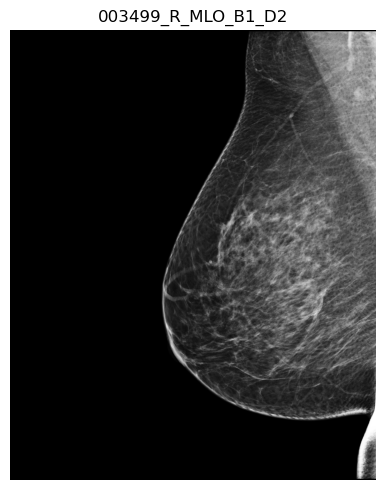

In [6]:
# figure, axis, image = show_dicom_image(image_index=idx)
figsize = (5, 5)

figure, axis = plt.subplots(figsize=figsize)
axis.imshow(original_image, cmap='gray')
axis.set_title(dicom_paths[idx].name)
axis.axis("off")
figure.tight_layout()

In [7]:
## Creo que normalize photometric ya hace la comprobación de si hay que invertir o no, pero por si acaso lo dejo
print(should_invert_monochrome1(metadata) )

#if should_invert_monochrome1(metadata):
original_image, _ = normalize_photometric(original_image, metadata)

False


## Windowing

In [ ]:

voilut = get_dicom_voi_lut_params(metadata)
print(voilut)

windowed_image = apply_windowing(original_image,
                                 window_width = voilut['window_width'],
                                 window_center = voilut['window_center'],
                                 voi_func = voilut['voi_lut_function'],
                                 y_min = original_image.min(),
                                 y_max =  original_image.max(), 
                                 backend = 'np_v2')

{'window_center': 2047, 'window_width': 4096, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


(0008,0005): (0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008): (0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY']
(0008,0014): (0008,0014) Instance Creator UID                UI: 1.2.840.113681.3232323428.1599656075.1240.1
(0008,0016): (0008,0016) SOP Class UID                       UI: Digital Mammography X-Ray Image Storage - For Presentation
(0008,0018): (0008,0018) SOP Instance UID                    UI: 1.2.840.113681.3232323428.1699601631.4812.41031
(0008,0020): (0008,0020) Study Date                          DA: '20231110'
(0008,0021): (0008,0021) Series Date                         DA: '20231110'
(0008,0022): (0008,0022) Acquisition Date                    DA: '20231110'
(0008,0023): (0008,0023) Content Date                        DA: '20231110'
(0008,0030): (0008,0030) Study Time                          TM: '155803'
(0008,0031): (0008,0031) Series Time                         TM: '160011'
(0008,0032): (0008,0032) Acquisition

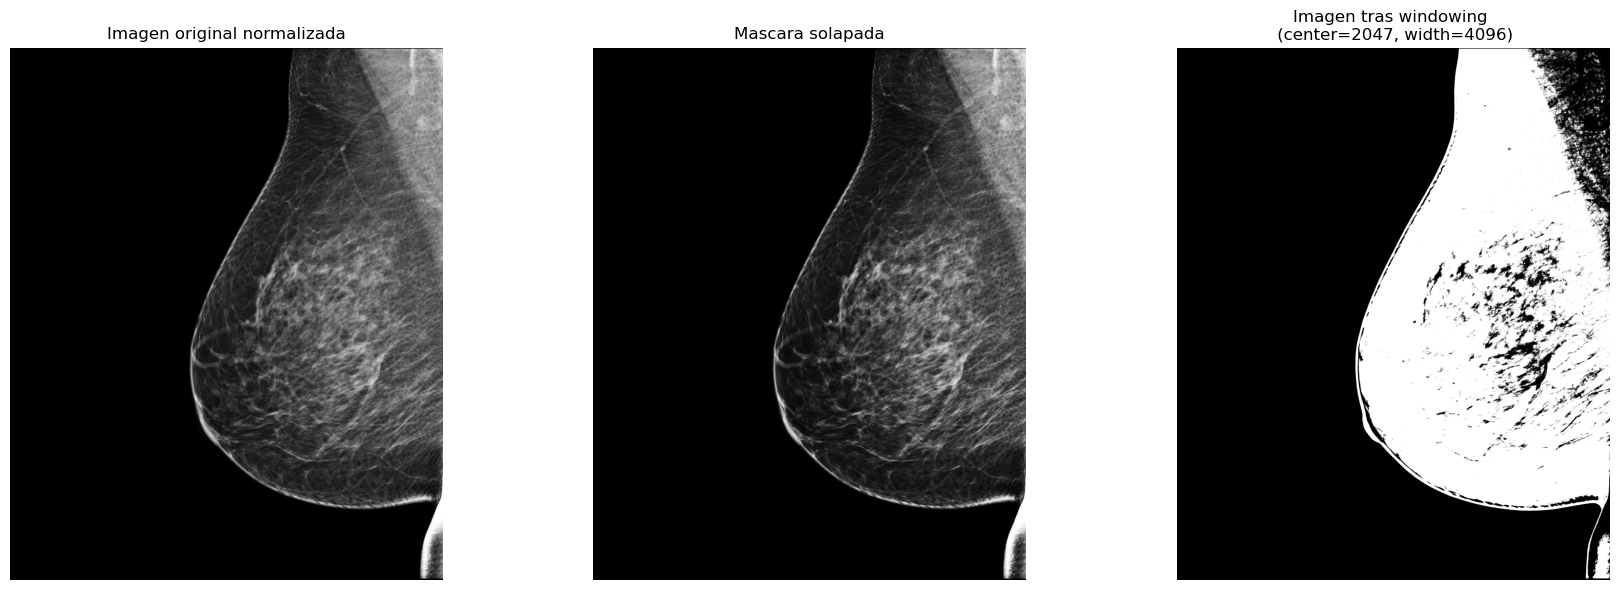

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Imagen original normalizada')
axes[0].axis('off')

axes[1].imshow(windowed_image, cmap='gray')
#axes[1].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[1].set_title('Mascara solapada')
axes[1].axis('off')

axes[2].imshow(windowed_image - original_image, cmap='gray')
#axes[2].imshow(breast_mask, cmap='autumn', alpha=0.25)
axes[2].set_title(f'Imagen tras windowing \n (center={voilut["window_center"]}, width={voilut["window_width"]})')
axes[2].axis('off')

figure.tight_layout()

visible_metadata = {
    key: value
    for key, value in metadata.items()
    if value not in (None, '', [], {})
}

for key, value in visible_metadata.items():
    print(f'{key}: {value}')

## Incluir localización del pecho

In [ ]:
import csv
import pandas as pd

INBREAST_CSV = Path('/home/eloygarcia/Escritorio/Datasets/INbreast/INBreast_breast_region.csv')

# Load CSV into a list of dicts
#with INBREAST_CSV.open(newline='', encoding='utf-8') as f:
#    records = list(csv.DictReader(f))
records = pd.read_csv(INBREAST_CSV)#.to_dict(orient='records')

print(f"Total annotations: {len(records)}")
print("Sample row:", records.iloc[0])